# Solve 1D Diffusion Equation with PIGP

In [2]:
import jax.numpy as jnp
import jax

In [3]:
D = 1
f = lambda x: 0
u0 = 1.0
uL = 0.0
X_coll = jnp.linspace(0.0, 1.0, 100).reshape(-1, 1)

In [4]:
import jax.numpy as jnp
from jax import grad

# Assume 'k' and 'f' are functions of x (defined outside)

def compute_residual(mu_u_fn, x):
    # 1. Compute the first derivative (flux derivative)
    du_dx = grad(mu_u_fn)(x)

    # 2. Compute the flux J = k * du/dx
    #    We need to define a closure/wrapper function for the flux J(x)
    def flux_fn(x):
        # NOTE: If k(x) is a constant, this is simpler: k * grad(mu_u_fn)(x)
        return k(x) * grad(mu_u_fn)(x)

    # 3. Compute the second derivative (divergence of flux)
    dJ_dx = grad(flux_fn)(x)

    # 4. Calculate the residual r(x)
    return dJ_dx + f(x)

# Example: r_x = compute_residual(lambda x: gp_posterior_mean(x, params), x_coll)

In [5]:
import gpjax as gpx

/dolfinx-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
kernel = gpx.kernels.RBF()  # 1-dimensional input
meanf = gpx.mean_functions.Zero()
prior = gpx.gps.Prior(mean_function=meanf, kernel=kernel)

In [12]:
u_gp_mean_func = lambda x: prior.predict(x).mean

In [37]:
u_gp_mean_func(X_coll[:1])

Array([0.], dtype=float32)

In [42]:
du_dx = jnp.diag(jax.jacfwd(u_gp_mean_func, 0)(X_coll)[:, :, 0])

In [ ]:
prior

Prior( # PositiveReal: 1 (4 B), NonNegativeReal: 1 (4 B), Total: 2 (8 B)
  kernel=RBF( # PositiveReal: 1 (4 B), NonNegativeReal: 1 (4 B), Total: 2 (8 B)
    active_dims=slice(None, None, None),
    n_dims=None,
    compute_engine=<gpjax.kernels.computations.dense.DenseKernelComputation object at 0x7fa6df709520>,
    lengthscale=PositiveReal( # 1 (4 B)
      value=Array(1., dtype=float32, weak_type=True),
      tag='positive'
    ),
    variance=NonNegativeReal( # 1 (4 B)
      value=Array(1., dtype=float32, weak_type=True),
      tag='non_negative'
    )
  ),
  mean_function=Zero(
    constant=Array(0., dtype=float32, weak_type=True)
  ),
  jitter=1e-06
)

In [ ]:
gpx.parameters.Parameter

<function flax.nnx.variablelib.Variable.get_metadata(self, name: 'str | None' = None, default: 'tp.Any' = <flax.typing.Missing object at 0x7fa7b82c38f0>, *, exclude_required: 'bool | None' = None) -> 'tp.Any'>

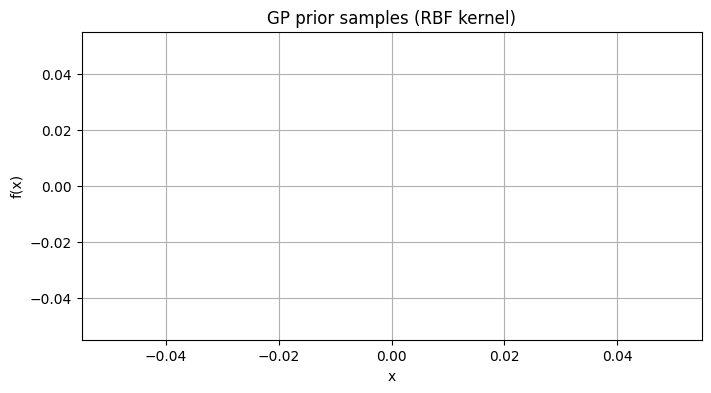

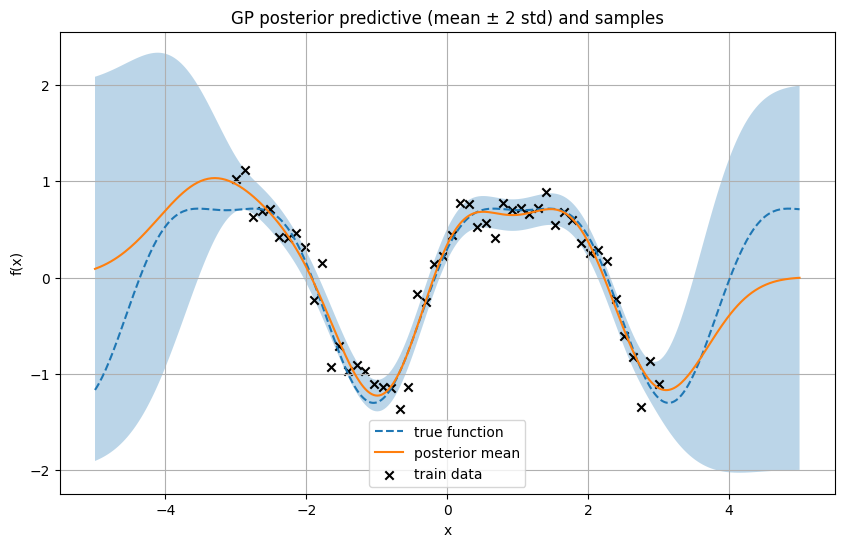

Log marginal likelihood: -9.366947174072266


In [72]:
# gp_jax.py
# Gaussian Process from scratch using JAX
# Requirements: jax, jaxlib, numpy, matplotlib

import jax
import jax.numpy as jnp
from jax import jit, vmap
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Kernel: Squared Exponential (RBF)
# -------------------------
def rbf_kernel(x1, x2, lengthscale=1.0, variance=1.0):
    """
    x1: shape (N, d)
    x2: shape (M, d)
    returns kernel matrix shape (N, M)
    """
    # make sure arrays are 2D
    x1 = jnp.atleast_2d(x1)
    x2 = jnp.atleast_2d(x2)
    # squared distances
    # using (a-b)^2 = a^2 + b^2 - 2ab
    x1_sq = jnp.sum(x1 ** 2, axis=1, keepdims=True)   # (N,1)
    x2_sq = jnp.sum(x2 ** 2, axis=1, keepdims=True)   # (M,1)
    sqdist = x1_sq + x2_sq.T - 2.0 * (x1 @ x2.T)
    return variance * jnp.exp(-0.5 * sqdist / (lengthscale ** 2))


# -------------------------
# Utility: jittered Cholesky for numerical stability
# -------------------------
def jittered_cholesky(K, jitter=1e-6):
    # ensure symmetric
    K_sym = 0.5 * (K + K.T)
    try:
        L = jnp.linalg.cholesky(K_sym)
    except Exception:
        # fallback: add jitter and try again
        L = jnp.linalg.cholesky(K_sym + jitter * jnp.eye(K.shape[0]))
    return L


# -------------------------
# GP prior sampling
# -------------------------
def gp_prior_samples(key, X, kernel_fn, n_samples=1):
    """
    Sample from GP prior at inputs X (N x d).
    Returns samples shape (n_samples, N)
    """
    K = kernel_fn(X, X)
    L = jittered_cholesky(K)
    N = X.shape[0]
    z = jax.random.normal(key, shape=(n_samples, N))
    # shapes: L (N,N), z (n_samples, N) -> multiply each sample by L
    return (z @ L.T)


# -------------------------
# Posterior predictive (analytic)
# -------------------------
def gp_posterior_predictive(X_train, y_train, X_test, kernel_fn, noise=1e-2):
    """
    Computes posterior predictive mean and covariance at X_test,
    conditioned on (X_train, y_train).
    Returns: mean (M,), cov (M,M)
    """
    K_tt = kernel_fn(X_test, X_test)            # K_**
    K_tn = kernel_fn(X_test, X_train)           # K_*n
    K_nn = kernel_fn(X_train, X_train)          # K_nn
    # add noise variance on diagonal of training covariance
    K_nn_noise = K_nn + (noise + 0.0) * jnp.eye(K_nn.shape[0])
    L = jittered_cholesky(K_nn_noise)
    # solve for alpha: (K_nn + σ^2 I)^{-1} y
    # use triangular solves: L L^T alpha = y -> first solve L v = y, then L^T alpha = v
    v = jax.scipy.linalg.solve_triangular(L, y_train, lower=True)
    alpha = jax.scipy.linalg.solve_triangular(L.T, v, lower=False)
    # mean
    mean = K_tn @ alpha
    # covariance: K_tt - K_tn (K_nn + σ^2 I)^{-1} K_nt
    # first compute w = solve(L, K_tn.T)
    w = jax.scipy.linalg.solve_triangular(L, K_tn.T, lower=True)
    cov = K_tt - (w.T @ w)
    # ensure sym
    cov = 0.5 * (cov + cov.T)
    return mean, cov


# -------------------------
# Log marginal likelihood (for hyperparameter tuning)
# -------------------------
def log_marginal_likelihood(X_train, y_train, kernel_fn, noise=1e-2):
    """
    Computes log p(y | X, θ) assuming zero mean GP prior.
    """
    K_nn = kernel_fn(X_train, X_train) + noise * jnp.eye(X_train.shape[0])
    L = jittered_cholesky(K_nn)
    # compute alpha as in predictive
    v = jax.scipy.linalg.solve_triangular(L, y_train, lower=True)
    alpha = jax.scipy.linalg.solve_triangular(L.T, v, lower=False)
    term1 = -0.5 * (y_train @ alpha)
    term2 = -jnp.sum(jnp.log(jnp.diag(L)))
    term3 = -0.5 * X_train.shape[0] * jnp.log(2.0 * jnp.pi)
    return term1 + term2 + term3


# -------------------------
# Simple helper: update dataset and recompute posterior
# -------------------------
def update_dataset(X_train, y_train, x_new, y_new):
    """
    Append a new datapoint (x_new, y_new) to training arrays.
    x_new should be shape (d,) or (1,d); returns new arrays.
    """
    x_new = jnp.atleast_2d(x_new)
    if X_train is None:
        return x_new, jnp.atleast_1d(y_new)
    else:
        X_new = jnp.vstack([X_train, x_new])
        y_new = jnp.atleast_1d(y_new)
        y_new = jnp.concatenate([y_train, jnp.atleast_1d(y_new)])
        return X_new, y_new


# -------------------------
# Example: 1D regression demo
# -------------------------
def demo_1d_regression(seed=0):
    key = jax.random.PRNGKey(seed)
    # True function
    f = lambda x: jnp.sin(1.5 * x) + 0.3 * jnp.cos(3.0 * x)

    # Training data (small)
    X_train = jnp.linspace(-3.0, 3.0, 50).reshape(-1, 1)
    y_train = f(X_train).ravel() + 0.2 * jax.random.normal(key, shape=(X_train.shape[0],))

    # Test points for plotting predictive
    X_test = jnp.linspace(-5.0, 5.0, 400).reshape(-1, 1)

    # Kernel hyperparameters
    lengthscale = 0.8
    variance = 1.0
    noise = 0.2 ** 2

    kernel = lambda a, b: rbf_kernel(a, b, lengthscale=lengthscale, variance=variance)

    # Prior samples
    key, subk = jax.random.split(key)
    prior_samps = gp_prior_samples(subk, X_test, kernel, n_samples=3)  # shape (3, M)

    # Posterior
    mean_post, cov_post = gp_posterior_predictive(X_train, y_train, X_test, kernel, noise=noise)

    # draw posterior samples
    L_post = jittered_cholesky(cov_post + 1e-8 * jnp.eye(cov_post.shape[0]))
    key, subk = jax.random.split(key)
    z = jax.random.normal(subk, shape=(3, X_test.shape[0]))
    post_samps = z @ L_post.T + mean_post

    # Convert to numpy for plotting
    X_test_np = np.array(X_test).ravel()
    mean_np = np.array(mean_post)
    std_np = np.sqrt(np.maximum(0.0, np.array(jnp.diag(cov_post))))
    prior_np = np.array(prior_samps)
    post_np = np.array(post_samps)
    X_train_np = np.array(X_train).ravel()
    y_train_np = np.array(y_train).ravel()
    true_np = np.array(f(X_test)).ravel()

    # Plot prior samples
    plt.figure(figsize=(8, 4))
    for i in range(prior_np.shape[0]):
        plt.plot(X_test_np, prior_np[i, :])
    plt.title("GP prior samples (RBF kernel)")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True)
    plt.show()

    # Plot posterior mean, uncertainty, samples, and data
    plt.figure(figsize=(10, 6))
    plt.plot(X_test_np, true_np, linestyle="--", label="true function")
    plt.plot(X_test_np, mean_np, label="posterior mean")
    plt.fill_between(X_test_np, mean_np - 2.0 * std_np, mean_np + 2.0 * std_np, alpha=0.3)
    for i in range(post_np.shape[0]):
        plt.plot(X_test_np, post_np[i, :], alpha=0.8)
    plt.scatter(X_train_np, y_train_np, c="k", marker="x", label="train data")
    plt.title("GP posterior predictive (mean ± 2 std) and samples")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print marginal likelihood
    ml = log_marginal_likelihood(X_train, y_train, kernel, noise=noise)
    print("Log marginal likelihood:", float(ml))

    return {
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "mean_post": mean_post,
        "cov_post": cov_post,
        "prior_samples": prior_samps,
        "posterior_samples": post_samps,
        "log_marginal_likelihood": ml
    }


# If run as script, execute demo
if __name__ == "__main__":
    demo_1d_regression()


In [67]:
def rbf_kernel(x1, x2, lengthscale=1.0, variance=1.0):
    """
    x1: shape (N, d)
    x2: shape (M, d)
    returns kernel matrix shape (N, M)
    """
    # make sure arrays are 2D
    x1 = jnp.atleast_2d(x1)
    x2 = jnp.atleast_2d(x2)
    # squared distances
    # using (a-b)^2 = a^2 + b^2 - 2ab
    x1_sq = jnp.sum(x1 ** 2, axis=1, keepdims=True)   # (N,1)
    x2_sq = jnp.sum(x2 ** 2, axis=1, keepdims=True)   # (M,1)
    sqdist = x1_sq + x2_sq.T - 2.0 * (x1 @ x2.T)
    return variance * jnp.exp(-0.5 * sqdist / (lengthscale ** 2))

In [73]:
X_train = jnp.linspace(0.0, 1.0, 10).reshape(-1, 1)
# y_train = f(X_train).ravel() + 0.2 * jax.random.normal(key, shape=(X_train.shape[0],))

# Test points for plotting predictive
X_test = jnp.linspace(0.0, 1.0, 10).reshape(-1, 1)

In [74]:
rbf_kernel(X_train, X_test)

Array([[1.        , 0.9938462 , 0.975611  , 0.94595945, 0.9059552 ,
        0.8569969 , 0.8007374 , 0.73899126, 0.67363846, 0.60653067],
       [0.9938462 , 1.        , 0.9938462 , 0.975611  , 0.94595945,
        0.9059552 , 0.8569969 , 0.8007374 , 0.73899126, 0.67363846],
       [0.975611  , 0.9938462 , 1.        , 0.9938462 , 0.975611  ,
        0.94595945, 0.9059552 , 0.8569969 , 0.8007374 , 0.73899126],
       [0.94595945, 0.975611  , 0.9938462 , 1.        , 0.9938462 ,
        0.975611  , 0.94595945, 0.9059552 , 0.8569969 , 0.8007374 ],
       [0.9059552 , 0.94595945, 0.975611  , 0.9938462 , 1.        ,
        0.9938462 , 0.975611  , 0.94595945, 0.9059552 , 0.8569969 ],
       [0.8569969 , 0.9059552 , 0.94595945, 0.975611  , 0.9938462 ,
        1.        , 0.9938462 , 0.975611  , 0.94595945, 0.9059552 ],
       [0.8007374 , 0.8569969 , 0.9059552 , 0.94595945, 0.975611  ,
        0.9938462 , 1.        , 0.99384624, 0.975611  , 0.9459595 ],
       [0.73899126, 0.8007374 , 0.8569969

In [79]:
import jax
import jax.numpy as jnp

def fem_poisson_1d(f, N):
    """
    FEM for -u'' = f on (0,1), u(0)=u(1)=0.
    Linear P1 elements. Uniform mesh.

    f: function taking x array → f(x) array
    N: number of elements (N+1 nodes)
    """

    # --- Mesh ---
    x = jnp.linspace(0.0, 1.0, N+1)
    h = 1.0 / N

    # --- Element stiffness matrix (P1 on [0,h]) ---
    Ke = (1.0 / h) * jnp.array([[1., -1.],
                                [-1., 1.]])

    # --- Element load vector with midpoint quadrature ---
    # Fe = f(x_mid) * h/2 * [1, 1]
    def assemble_load(f):
        # Midpoint of each element
        x_mid = 0.5 * (x[:-1] + x[1:])
        vals = f(x_mid)
        Fe = (h / 2.0) * jnp.stack([vals, vals], axis=1)  # shape (N, 2)
        return Fe

    Fe_all = assemble_load(f)

    # --- Global matrix / vector ---
    K = jnp.zeros((N+1, N+1))
    F = jnp.zeros(N+1)

    def element_assembly(carry, e):
        K_acc, F_acc = carry
        nodes = jnp.array([e, e+1])
        K_acc = K_acc.at[nodes[:,None], nodes[None,:]].add(Ke)
        F_acc = F_acc.at[nodes].add(Fe_all[e])
        return (K_acc, F_acc), None

    (K, F), _ = jax.lax.scan(
        element_assembly,
        (K, F),
        jnp.arange(N)
    )

    # --- Apply Dirichlet BCs (u(0)=u(1)=0) ---
    K = K[1:-1, 1:-1]
    F = F[1:-1]

    # --- Solve ---
    u_inner = jnp.linalg.solve(K, F)

    # Insert BCs
    u = jnp.concatenate([jnp.array([0.0]), u_inner, jnp.array([0.0])])

    return x, u, K, F


In [81]:
N = 50

def f(x):
    return jnp.sin(jnp.pi * x)

x, u, K, F = fem_poisson_1d(f, N)
print(u)


[0.         0.00636098 0.01269685 0.01898262 0.02519347 0.03130489
 0.03729277 0.04313346 0.04880393 0.05428179 0.05954543 0.06457407
 0.06934787 0.07384798 0.07805665 0.08195726 0.08553442 0.08877402
 0.09166326 0.09419075 0.09634652 0.09812205 0.09951035 0.10050592
 0.10110483 0.10130472 0.10110481 0.10050589 0.0995103  0.098122
 0.09634645 0.09419067 0.09166317 0.08877391 0.08553432 0.08195715
 0.07805653 0.07384786 0.06934775 0.06457396 0.05954532 0.05428169
 0.04880383 0.04313337 0.03729269 0.03130482 0.02519341 0.01898258
 0.01269682 0.00636096 0.        ]


ValueError: x and y must have same first dimension, but have shapes (51,) and (49,)

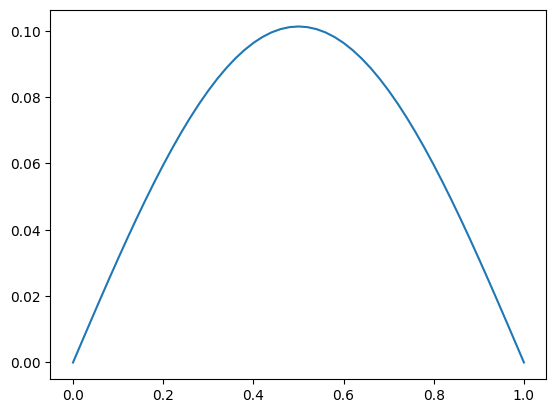

In [89]:
plt.plot(x, u)
plt.plot(x, F)

In [84]:
K.shape

(49, 49)

In [85]:
F.shape

(49,)

In [188]:
# jax_fem_gp_residual.py
import jax
import jax.numpy as jnp
from jax.scipy.linalg import solve  # linear solves (wraps fast backends)

# ------------------------
# FEM assembly (linear P1, uniform mesh)
# ------------------------
def build_mesh(N):
    """Return nodes x (N+1 nodes) and element size h."""
    x = jnp.linspace(0.0, 1.0, N + 1)
    h = 1.0 / N
    return x, h

def assemble_fem(N, f_fn):
    """
    Assemble stiffness matrix K (global) and load vector F using midpoint rule.
    Return K_full (size (N+1,N+1)), F_full (N+1).
    Boundary nodes are included (we'll remove them later for Dirichlet).
    """
    x, h = build_mesh(N)
    # element stiffness for two-node element
    Ke = (1.0 / h) * jnp.array([[1.0, -1.0],
                                [-1.0, 1.0]])
    # element load using midpoint rule: Fe = h * f(mid) * [1/2, 1/2]
    x_mid = 0.5 * (x[:-1] + x[1:])
    f_mid = f_fn(x_mid)
    Fe_each = (h * f_mid * 0.5)  # scalar per element for each entry

    K = jnp.zeros((N + 1, N + 1))
    F = jnp.zeros(N + 1)

    def body(i, carry):
        K_loc, F_loc = carry
        nodes = jnp.array([i, i + 1])
        K_loc = K_loc.at[nodes[:, None], nodes[None, :]].add(Ke)
        F_loc = F_loc.at[nodes].add(jnp.array([Fe_each[i], Fe_each[i]]))
        return K_loc, F_loc

    K, F = jax.lax.fori_loop(0, N, body, (K, F))
    return K, F, x

# ------------------------
# RBF kernel (prior covariance)
# ------------------------
def rbf_kernel(x1, x2, variance=1.0, lengthscale=0.2):
    """Compute RBF kernel matrix between x1 and x2."""
    # x1: (n1,), x2: (n2,)
    x1 = x1[:, None]
    x2 = x2[None, :]
    d2 = (x1 - x2) ** 2
    K = variance * jnp.exp(-0.5 * d2 / (lengthscale ** 2))
    return K

# ------------------------
# GP conditioning on residuals r = K_int u_int - F_int ≈ 0
# (A = K_int; observations are b = F_int, modeled as A u = b with noise)
# ------------------------
def condition_gp_on_residual(N,
                             f_fn,
                             prior_variance=1.0,
                             prior_lengthscale=0.2,
                             residual_noise=1e-6,
                             jitter=1e-8):

    # assemble FEM
    K_full, F_full, x = assemble_fem(N, f_fn)

    # Dirichlet BCs:
    u0 = 0.0      # left BC
    uN = 0.5      # right BC

    # interior indices = 1,...,N-1
    K_int = K_full[1:-1, 1:-1]       # (N-1,N-1)
    F_int = F_full[1:-1].copy()      # (N-1,)

    # modify RHS for Dirichlet corrections:
    # F_i -= K_int(:,0)*u0 + K_int(:,N)*uN
    # left BC term is zero because u0=0
    F_int = F_int - K_full[1:-1, -1] * uN

    # prior covariance on all nodes then restrict
    Kprior_full = rbf_kernel(x, x,
                             variance=prior_variance,
                             lengthscale=prior_lengthscale)
    Sigma_ii = Kprior_full[1:-1, 1:-1]

    m_i = jnp.zeros_like(F_int)

    A = K_int
    S = A @ Sigma_ii @ A.T + (residual_noise + jitter) * jnp.eye(A.shape[0])

    rhs = F_int - A @ m_i
    alpha = solve(S, rhs)

    mu_post_i = m_i + Sigma_ii @ (A.T @ alpha)  # posterior interior mean

    # posterior covariance
    update = Sigma_ii @ (A.T @ solve(S, A @ Sigma_ii))
    Sigma_post_i = Sigma_ii - update

    # full posterior vector INCLUDING the new Dirichlet BCs
    mu_post_full = jnp.concatenate([jnp.array([u0]),  # left BC = 0
                                    mu_post_i,
                                    jnp.array([uN])]) # right BC = 1

    return {
        "x": x,
        "mu_post_full": mu_post_full,
        "Sigma_post_i": Sigma_post_i,
        "Sigma_ii": Sigma_ii,
        "interior_idx": jnp.arange(1, N),
        "K_int": K_int,
        "F_int": F_int,
        "prior_full": Kprior_full,
        "u0": u0,
        "uN": uN
    }

def predict_posterior_mean_and_cov(info,
                                   x_star,
                                   prior_variance=1.0,
                                   prior_lengthscale=0.2,
                                   jitter=1e-10):

    x = info["x"]
    mu_full = info["mu_post_full"]
    mu_i = mu_full[1:-1]          # interior only
    Sigma_ii = info["Sigma_ii"]

    # K(x*, x_i)
    K_s_i = rbf_kernel(
        x_star, x[1:-1],
        variance=prior_variance,
        lengthscale=prior_lengthscale
    )

    K_s_s = rbf_kernel(
        x_star, x_star,
        variance=prior_variance,
        lengthscale=prior_lengthscale
    )

    # predictive mean
    w = solve(Sigma_ii, mu_i)
    mu_star = K_s_i @ w

    # predictive covariance
    M = solve(Sigma_ii, K_s_i.T)
    Sigma_star = K_s_s - K_s_i @ M + jitter * jnp.eye(len(x_star))

    return mu_star, Sigma_star


# ------------------------
# Vectorized version: condition for many RHS functions f
# ------------------------
def batch_condition_gp(N, f_batch_fn_list, **kwargs):
    """
    f_batch_fn_list: list or array-like of functions f(x_mid) -> values.
    For convenience we'll accept a Python list of callables and vmap over them by evaluating
    each callable separately. Alternatively you could pass an array of discrete F vectors and
    vmap over those.
    Returns list of info dicts (one per f).
    """
    def work_single(f_fn):
        return condition_gp_on_residual(N, f_fn, **kwargs)

    # note: jax.vmap doesn't handle Python callables list directly, so we just use Python loop
    # for moderate batch sizes this is fine. If you supply discrete F vectors we can fully vmap.
    return [work_single(fn) for fn in f_batch_fn_list]

# ------------------------
# Example usage
# ------------------------


In [189]:

N = 7

# define f as a function that accepts array of midpoints and returns values
def f_fn(x):
    return jnp.sin(2 * jnp.pi * x)  # example
variance = 1.5
length_scale = 0.25
info = condition_gp_on_residual(
    N,
    f_fn,
    prior_variance=variance,
    prior_lengthscale=length_scale,
    residual_noise=1e-8,
    jitter=1e-10,
)

x = info["x"]
mu_post = info["mu_post_full"]           # posterior mean at all nodes (boundaries included)
Sigma_post_i = info["Sigma_post_i"]      # posterior covariance for interior nodes

print("nodes x shape:", x.shape)
print("posterior mean (nodes):", mu_post)

# Predict at fine grid
x_star = jnp.linspace(0.0, 1.0, 100)

mu_star,covar_star = predict_posterior_mean_and_cov(info, x_star, variance, length_scale)
print("predictive mean at x_star shape:", mu_star.shape)


nodes x shape: (8,)
posterior mean (nodes): [0.         0.09051948 0.16666293 0.2248807  0.27512008 0.33333752
 0.4094808  0.5       ]
predictive mean at x_star shape: (100,)


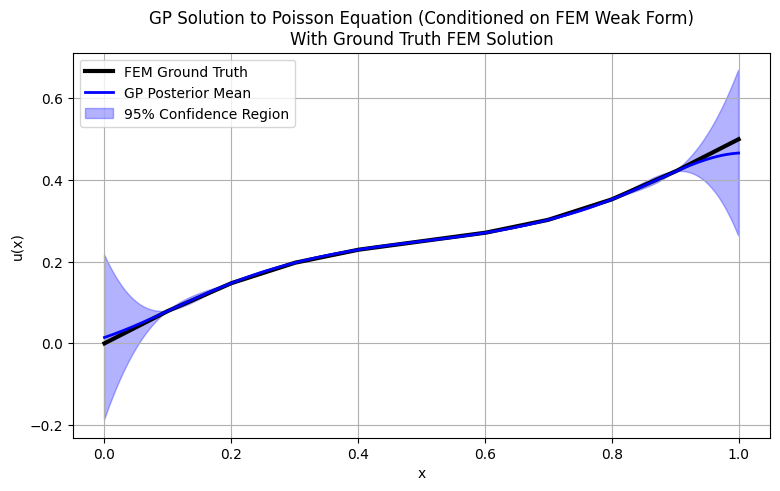

In [212]:
if __name__ == "__main__":

    # -----------------------------------------
    # Problem setup
    # -----------------------------------------
    N = 10
    f_fn = lambda x: 2 * jnp.sin(2 * jnp.pi * x)

    # Condition GP on FEM residual
    info = condition_gp_on_residual(N, f_fn, prior_variance=1.0, prior_lengthscale=0.2)

    # -----------------------------------------
    # Ground truth FEM solution (deterministic)
    # -----------------------------------------
    K_full, F_full, x = assemble_fem(N, f_fn)

    # Apply the non-zero Dirichlet boundary conditions to RHS
    u0 = info["u0"]  # left BC
    uN = info["uN"]  # right BC

    # interior stiffness and load
    K_int = K_full[1:-1, 1:-1]
    F_int = F_full[1:-1] - K_full[1:-1, -1] * uN  # correct RHS

    # solve Ku = F for interior nodes
    u_int = solve(K_int, F_int)
    u_fem = jnp.concatenate([jnp.array([u0]), u_int, jnp.array([uN])])

    # -----------------------------------------
    # GP posterior prediction at fine grid
    # -----------------------------------------
    x_star = jnp.linspace(0., 1., 400)
    mu_star, Sigma_star = predict_posterior_mean_and_cov(
        info, x_star
    )
    std = jnp.sqrt(jnp.diag(Sigma_star))

    # interpolate the FEM solution on x_star for smooth plotting
    u_fem_interp = jnp.interp(x_star, x, u_fem)

    # -----------------------------------------
    # PLOT
    # -----------------------------------------
    import matplotlib.pyplot as plt

    plt.figure(figsize=(9,5))

    # FEM truth
    plt.plot(x_star, u_fem_interp,
             label="FEM Ground Truth",
             linewidth=3, color="black")

    # GP posterior mean
    plt.plot(x_star, mu_star,
             label="GP Posterior Mean",
             linewidth=2, color="blue")

    # # 95% confidence interval
    plt.fill_between(
        x_star,
        mu_star - 2*std,
        mu_star + 2*std,
        alpha=0.3,
        color="blue",
        label="95% Confidence Region"
    )

    plt.xlabel("x")
    plt.ylabel("u(x)")
    plt.legend()
    plt.title("GP Solution to Poisson Equation (Conditioned on FEM Weak Form)\n"
              "With Ground Truth FEM Solution")
    plt.grid(True)
    plt.show()


In [166]:
std = jnp.sqrt(jnp.diag(covar_star))

In [167]:
import matplotlib.pyplot as plt

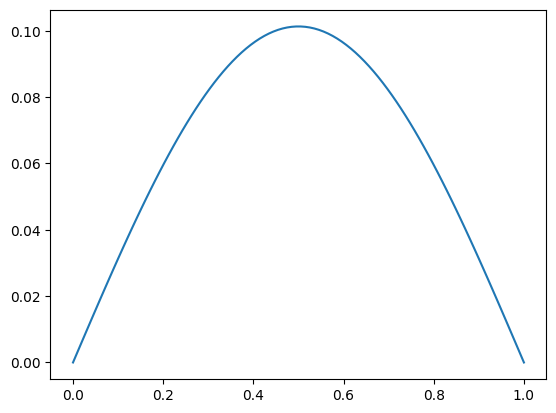

In [170]:
# plt.plot(x_star, mu_star)
plt.plot(x_star, 1/jnp.pi**2 * jnp.sin(jnp.pi * x_star))
# plt.fill_between(x_star,
#                      mu_star - 2*std,
#                      mu_star + 2*std,
#                      alpha=0.3,
#                      label="95% CI")

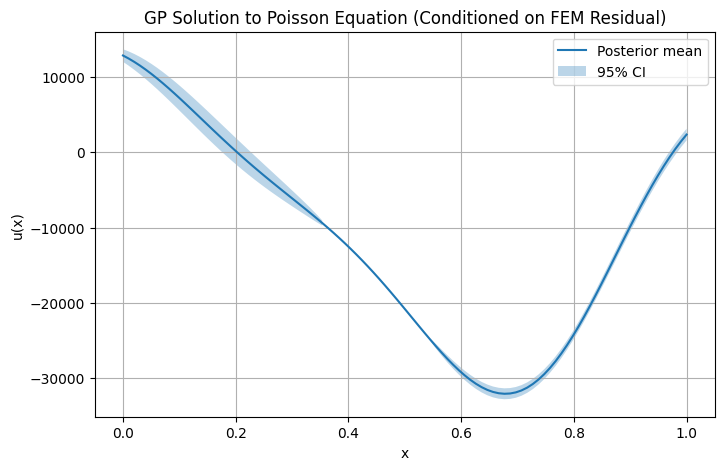

In [115]:
import jax
import jax.numpy as jnp
from jax.scipy.linalg import solve
import matplotlib.pyplot as plt

# ===============================
# RBF kernel
# ===============================
def rbf_kernel(x1, x2, variance=1.0, lengthscale=0.2):
    x1 = x1[:, None]
    x2 = x2[None, :]
    sq = (x1 - x2)**2
    return variance * jnp.exp(-0.5 * sq / lengthscale**2)

# ===============================
# FEM (P1 on uniform mesh)
# ===============================
def build_mesh(N):
    x = jnp.linspace(0., 1., N+1)
    h = 1.0 / N
    return x, h

def assemble_fem(N, f_fn):
    x, h = build_mesh(N)
    Ke = (1/h) * jnp.array([[1., -1.],
                            [-1., 1.]])

    # midpoint quadrature for load
    x_mid = 0.5 * (x[:-1] + x[1:])
    f_mid = f_fn(x_mid)
    Fe_elem = h * f_mid * 0.5

    K = jnp.zeros((N+1, N+1))
    F = jnp.zeros(N+1)

    def body(i, carry):
        Kc, Fc = carry
        nodes = jnp.array([i, i+1])
        Kc = Kc.at[nodes[:,None], nodes[None,:]].add(Ke)
        Fc = Fc.at[nodes].add(jnp.array([Fe_elem[i], Fe_elem[i]]))
        return Kc, Fc

    K, F = jax.lax.fori_loop(0, N, body, (K, F))
    return K, F, x

# ===============================
# GP conditioning on FEM residuals
# ===============================
def condition_gp_on_residual(
    N, f_fn,
    prior_variance=1.0,
    prior_lengthscale=0.2,
    residual_noise=1e-8,
    jitter=1e-10,
):

    K_full, F_full, x = assemble_fem(N, f_fn)

    K_int = K_full[1:-1, 1:-1]
    F_int = F_full[1:-1]

    # prior covariance on nodes
    Kprior_full = rbf_kernel(x, x,
                             variance=prior_variance,
                             lengthscale=prior_lengthscale)
    Sigma_ii = Kprior_full[1:-1, 1:-1]

    A = K_int
    S = A @ Sigma_ii @ A.T + (residual_noise+jitter) * jnp.eye(A.shape[0])

    rhs = F_int
    alpha = solve(S, rhs)

    mu_i = Sigma_ii @ (A.T @ alpha)

    update = Sigma_ii @ (A.T @ solve(S, A @ Sigma_ii))
    Sigma_post_i = Sigma_ii - update

    mu_full = jnp.concatenate([jnp.array([0.0]), mu_i, jnp.array([0.0])])

    return {
        "x": x,
        "mu_full": mu_full,
        "Sigma_post_i": Sigma_post_i,
        "prior_variance": prior_variance,
        "prior_lengthscale": prior_lengthscale,
    }

# ===============================
# Predictive mean & covariance
# ===============================
def predict_mean_and_cov(info, x_star, jitter=1e-10):
    x = info["x"]
    mu_full = info["mu_full"]
    mu_i = mu_full[1:-1]

    Sigma_ii = info["Sigma_post_i"]
    var = info["prior_variance"]
    ls = info["prior_lengthscale"]

    K_s_i = rbf_kernel(x_star, x[1:-1], variance=var, lengthscale=ls)
    K_s_s = rbf_kernel(x_star, x_star, variance=var, lengthscale=ls)

    w = solve(Sigma_ii, mu_i)
    mu_star = K_s_i @ w

    M = solve(Sigma_ii, K_s_i.T)
    Sigma_star = K_s_s - K_s_i @ M
    Sigma_star = Sigma_star + jitter * jnp.eye(len(x_star))

    return mu_star, Sigma_star


# ===============================
# MAIN: Solve & Plot
# ===============================
if __name__ == "__main__":
    N = 50
    f_fn = lambda x: jnp.sin(jnp.pi/2 * x)

    # condition GP on weak-form residual
    info = condition_gp_on_residual(N, f_fn)

    # prediction points
    x_star = jnp.linspace(0., 1., 100)

    mu_star, Sigma_star = predict_mean_and_cov(info, x_star)
    std = jnp.sqrt(jnp.diag(Sigma_star))

    # ======== PLOT ========
    plt.figure(figsize=(8,5))
    plt.plot(x_star, mu_star, label="Posterior mean")
    plt.fill_between(x_star,
                     mu_star - 2*std,
                     mu_star + 2*std,
                     alpha=0.3,
                     label="95% CI")

    plt.xlabel("x")
    plt.ylabel("u(x)")
    plt.title("GP Solution to Poisson Equation (Conditioned on FEM Residual)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [6]:
import jax 
import jax.numpy as jnp
from core.datasetclass import TractionDataset
from core.utils import C_func, I1_func, I2_func, I3_func

In [5]:
@jax.vmap
def transformation_jacobian(coords_elem) :
    x1, y1 = coords_elem[0]
    x2, y2 = coords_elem[1]
    x3, y3 = coords_elem[2]

    # Jacobian of shape function derivatives
    J = jnp.array([
        [x2 - x1, y2 - y1],
        [x3 - x1, y3 - y1]
    ])
    return J

@jax.vmap
def deformation_gradient_element(coords_elem, disp_elem):
    x1, y1 = coords_elem[0]
    x2, y2 = coords_elem[1]
    x3, y3 = coords_elem[2]

    # Jacobian of shape function derivatives
    J = jnp.array([
        [x2 - x1, y2 - y1],
        [x3 - x1, y3 - y1]
    ])

    # Area factor
    detJ = jnp.linalg.det(J)

    # Shape function derivatives in reference space
    dN_ref = jnp.array([
        [-1., -1.],
        [ 1.,  0.],
        [ 0.,  1.]
    ])

    # Convert to physical derivatives: dN/dx = inv(J)^T * dN_ref
    dNdx = jnp.transpose(jnp.linalg.solve(J, dN_ref.T))

    # Gradient of displacement
    gradu = disp_elem.T @ dNdx  # 2x3 @ 3x2 = 2x2

    # Deformation gradient
    F = jnp.eye(2) + gradu
    return F, dNdx

In [8]:
@jax.vmap
def get_I_dIdF(f) :
    c = f.T @ f
    i1 = jnp.trace(c)
    i2 = 0.5 * (jnp.trace(c) ** 2 - jnp.trace(c @ c))
    i3 = jnp.linalg.det(c)

    di1_dF = 2 * f
    di2_dF = 2 * (i1 * f - f @ c)
    di3_dF = 2 * (i3 * jnp.linalg.inv(f.T))

    invariants = jnp.stack([i1, i2, i3])
    dinvariants = jnp.stack([di1_dF, di2_dF, di3_dF])
    return invariants, dinvariants

$$R = H \delta\Phi - f_{ext}$$

In [ ]:
def H_matrix() :
    # h = jnp.zeros(n_nodes)
    return 

In [3]:
dataset = TractionDataset("dataset", "NH")
data = dataset[0]

In [120]:
n_nodes = data["mesh_pos"].shape[0]
cells = data["cells"]
coords_cells = data["mesh_pos"][:, :2][cells]
u_cells = data["u"][cells]
node_type = data["node_type"]

In [ ]:
n_nodes = data["mesh_pos"].shape[0]
cells = data["cells"]
coords_cells = data["mesh_pos"][:, :2][cells]
u_cells = data["u"][cells]
deformation_gradient, dNdx = deformation_gradient_element(coords_cells, u_cells)
dA = jnp.linalg.det(transformation_jacobian(coords_cells)) / 2
invariants, dinvariants = get_I_dIdF(deformation_gradient)

In [18]:
dA

Array([0.00091506, 0.00091506, 0.0007639 , 0.00086736, 0.001149  ,
       0.00103863, 0.00085473, 0.00092352, 0.00084445, 0.00100048,
       0.00108575, 0.00096207, 0.0009426 , 0.00117252, 0.00104427,
       0.00102286, 0.00115969, 0.00097672, 0.00094859, 0.00092977,
       0.0010411 , 0.00104968, 0.00103093, 0.00120418, 0.00098677,
       0.00101818, 0.00088342, 0.00104483, 0.001016  , 0.00103725,
       0.00107132, 0.00123835, 0.00083939, 0.00103713, 0.00070423,
       0.00101503, 0.00102573, 0.00099499, 0.00100476, 0.0010875 ,
       0.00110362, 0.00102659, 0.0009309 , 0.00085788, 0.00095721,
       0.00105548, 0.00101513, 0.00098409, 0.0009864 , 0.00104916,
       0.00111845, 0.00107669, 0.0011835 , 0.00083344, 0.00076378,
       0.00100832, 0.00109562, 0.00102442, 0.00098712, 0.00095851,
       0.00104832, 0.00109809, 0.00108409, 0.00121774, 0.00093655,
       0.00089548, 0.00110115, 0.00126515, 0.00125063, 0.0010198 ,
       0.00096069, 0.00094107, 0.00105496, 0.00108208, 0.00109

In [92]:
dinvariants.shape

(960, 3, 2, 2)

In [94]:
dNdx.shape

(960, 3, 2)

In [109]:
#per element
i0 = dinvariants[0]
d0 = dNdx[0]

In [ ]:
dinvariants[0, k, i, j] @ dNdx[0, a, j]

Array([-43.69257428,   0.06537385,  43.62720043], dtype=float64)

In [114]:
temp = jnp.einsum("ckij, caj -> ciak", dinvariants, dNdx)

In [116]:
temp.shape

(960, 2, 3, 3)

In [131]:
K_int_ele = dA[:, None, None, None] * temp

In [124]:
def _neumann_cell_force(coords_el, types_el, t3, t4):
    """
    coords_el: (3,2) float - coordinates of the 3 nodes of the element
    types_el:  (3,) int - node_type for these 3 nodes (global node_type[cells])
    t3, t4: scalars - traction magnitudes for types 3 and 4
    returns: (3,2) local nodal traction vector for this element
    """
    edges = jnp.array([[0, 1],
                       [1, 2],
                       [2, 0]])  # three local edges
    f_cell = jnp.zeros((3, 2))

    def body_fun(idx, f):
        i = edges[idx, 0]
        j = edges[idx, 1]

        ti = types_el[i]
        tj = types_el[j]

        # Only apply traction if both nodes of the edge have the same neumann type.
        is_right = (ti == 3) & (tj == 3)
        is_top   = (ti == 4) & (tj == 4)

        # choose traction vector for edge
        t_edge = jnp.where(is_right, jnp.array([t3, 0.0]),
                 jnp.where(is_top,   jnp.array([0.0, t4]),
                                         jnp.array([0.0, 0.0])))

        xi = coords_el[i]
        xj = coords_el[j]
        L = jnp.linalg.norm(xj - xi)

        # nodal contribution from this edge: each edge contributes L/2 * T to each of its two nodes
        fe_local = 0.5 * L * t_edge  # shape (2,)

        f = f.at[i].add(fe_local)
        f = f.at[j].add(fe_local)
        return f

    f_cell = jax.lax.fori_loop(0, 3, body_fun, f_cell)
    return f_cell  # (3,2)
f_ext = jax.vmap(_neumann_cell_force, in_axes=(0, 0, None, None))


In [126]:
f_ext_ele = f_ext(coords_cells, node_type[cells], 2, 2 * 1.1)

In [153]:
f0 = f_ext_ele[0, :, :]

In [154]:
f0

Array([[0.   , 0.055],
       [0.   , 0.   ],
       [0.   , 0.055]], dtype=float64)

In [155]:
K0 = K_int_ele[0]

In [156]:
jnp.linalg.solve(K0, f0)

Array([[[-0.00000000e+00, -8.00620636e+02],
        [ 0.00000000e+00, -4.05828370e+18],
        [ 0.00000000e+00,  4.05828370e+18]],

       [[            nan,             nan],
        [            nan,            -inf],
        [            nan,             inf]]], dtype=float64)

In [164]:
@jax.vmap
def get_deriv(K0, f0) :
    K_stacked = K0.reshape(-1, 3)  # shape (2*3, 3) = (6,3)
    b_stacked = f0.reshape(-1, 1)  # shape (6,1)
    x = jnp.linalg.pinv(K_stacked) @ b_stacked  # pinv handles non-invertible case
    return x

In [166]:
dPsi = get_deriv(K_int_ele, f_ext_ele)

In [170]:
(dPsi[:, 0] == 0).sum()


Array(921, dtype=int64)

In [169]:
dPsi.shape

(960, 3, 1)

In [159]:
x

Array([[ 2.89950952],
       [-1.03737366],
       [-1.03737366]], dtype=float64)